# 📊 Visualizing the BPE Training Process

In this notebook, we'll dive deeper into how BPE learns merges by visualizing the training process on a real dataset. We'll see how the vocabulary evolves and understand the frequency distribution of tokens.

In [6]:
import sys
sys.path.append('..')

import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
import pandas as pd
from tqdm import tqdm

# Optional: use project's GPT4Tokenizer for comparison
from src.bpe.tokenizer import GPT4Tokenizer

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("✅ Imports complete!")

✅ Imports complete!


## Load a Real Dataset

We'll use a small sample from the TinyStories dataset - a collection of simple stories written for children.

In [2]:
# Sample TinyStories data
tinystories_sample = [
    "Once upon a time, there was a little cat named Whiskers.",
    "Whiskers loved to play in the garden every sunny day.",
    "One day, Whiskers found a magical flower that could talk.",
    "The flower said, 'Hello, Whiskers! I can grant you three wishes.'",
    "Whiskers was surprised and didn't know what to wish for.",
    "First, Whiskers wished for a giant ball of yarn to play with.",
    "Suddenly, a huge colorful ball appeared in the garden.",
    "Whiskers played with the ball until the sun went down.",
    "For the second wish, Whiskers asked for a fish pond.",
    "A small pond with golden fish appeared near the flowers.",
    "Whiskers watched the fish swim and felt very happy.",
    "For the last wish, Whiskers wished for all animals to be friends.",
    "From that day on, all creatures in the garden lived peacefully.",
    "Whiskers learned that kindness and friendship are the best magic.",
    "The magical flower smiled and disappeared in a sparkle of light.",
    "Whiskers never forgot the day magic came to the garden.",
    "Every time Whiskers played with the yarn, it remembered.",
    "The golden fish always swam up to say hello to Whiskers.",
    "And the garden became the happiest place in the world.",
    "The end."
]

print(f"Loaded {len(tinystories_sample)} stories")
print("\nSample story:")
print(tinystories_sample[0])

Loaded 20 stories

Sample story:
Once upon a time, there was a little cat named Whiskers.


## Track Training Progress

Let's train our BPE tokenizer and track how the vocabulary evolves at each merge step.

In [3]:
from collections import defaultdict
class VisualBPETokenizer:
    """BPE tokenizer with training visualization capabilities."""
    
    def __init__(self, num_merges=50):
        self.num_merges = num_merges
        self.merges = []
        self.vocab = {}
        self.vocab_history = []
        self.merge_frequencies = []
        
    def train(self, corpus):
        """Train with progress tracking."""
        # Pre-tokenize and count frequencies
        word_freqs = Counter()
        for sentence in corpus:
            words = re.findall(r"\w+", sentence.lower())
            for word in words:
                word_freqs[word] += 1
        
        # Initialize vocabulary
        vocab = {}
        for word, freq in word_freqs.items():
            tokenized = ' '.join(list(word)) + ' </w>'
            vocab[tokenized] = freq
        
        print(f"Initial vocabulary size: {len(vocab)}")
        print(f"Total words in corpus: {sum(word_freqs.values())}")
        
        # Track initial state
        self._track_vocab_stats(vocab)
        
        # Training loop
        for i in tqdm(range(self.num_merges), desc="Merging"):
            # Get pair frequencies
            pairs = defaultdict(int)
            for word, freq in vocab.items():
                symbols = word.split()
                for j in range(len(symbols) - 1):
                    pairs[(symbols[j], symbols[j+1])] += freq
            
            if not pairs:
                break
            
            # Find best pair
            best_pair = max(pairs.items(), key=lambda x: x[1])[0]
            best_freq = pairs[best_pair]
            
            self.merges.append(best_pair)
            self.merge_frequencies.append(best_freq)
            
            # Merge
            merged = ''.join(best_pair)
            new_vocab = {}
            
            for word, freq in vocab.items():
                symbols = word.split()
                new_symbols = []
                j = 0
                
                while j < len(symbols):
                    if j < len(symbols) - 1 and symbols[j] == best_pair[0] and symbols[j+1] == best_pair[1]:
                        new_symbols.append(merged)
                        j += 2
                    else:
                        new_symbols.append(symbols[j])
                        j += 1
                
                new_vocab[' '.join(new_symbols)] = freq
            
            vocab = new_vocab
            
            # Track progress every 5 merges
            if (i + 1) % 5 == 0:
                self._track_vocab_stats(vocab)
        
        # Final vocabulary
        self._build_final_vocab()
        
        return self
    
    def _track_vocab_stats(self, vocab):
        """Track vocabulary statistics."""
        # Count unique tokens
        tokens = set()
        for word in vocab:
            tokens.update(word.split())
        
        # Calculate average token length
        token_lengths = [len(t) for t in tokens]
        
        self.vocab_history.append({
            'num_tokens': len(tokens),
            'avg_token_length': np.mean(token_lengths) if token_lengths else 0,
            'max_token_length': max(token_lengths) if token_lengths else 0
        })
    
    def _build_final_vocab(self):
        """Build final token-to-id mapping."""
        tokens = set()
        for merge in self.merges:
            tokens.add(merge[0])
            tokens.add(merge[1])
            tokens.add(''.join(merge))
        
        tokens.add('<unk>')
        tokens.add('<pad>')
        tokens.add('</w>')
        
        self.vocab = {token: idx for idx, token in enumerate(sorted(tokens))}

# Train with visualization
visual_tokenizer = VisualBPETokenizer(num_merges=30)
visual_tokenizer.train(tinystories_sample)

Initial vocabulary size: 105
Total words in corpus: 199


Merging: 100%|██████████| 30/30 [00:00<00:00, 4438.26it/s]


## 📈 Visualize Training Progress

Now let's create several visualizations to understand what's happening during training.

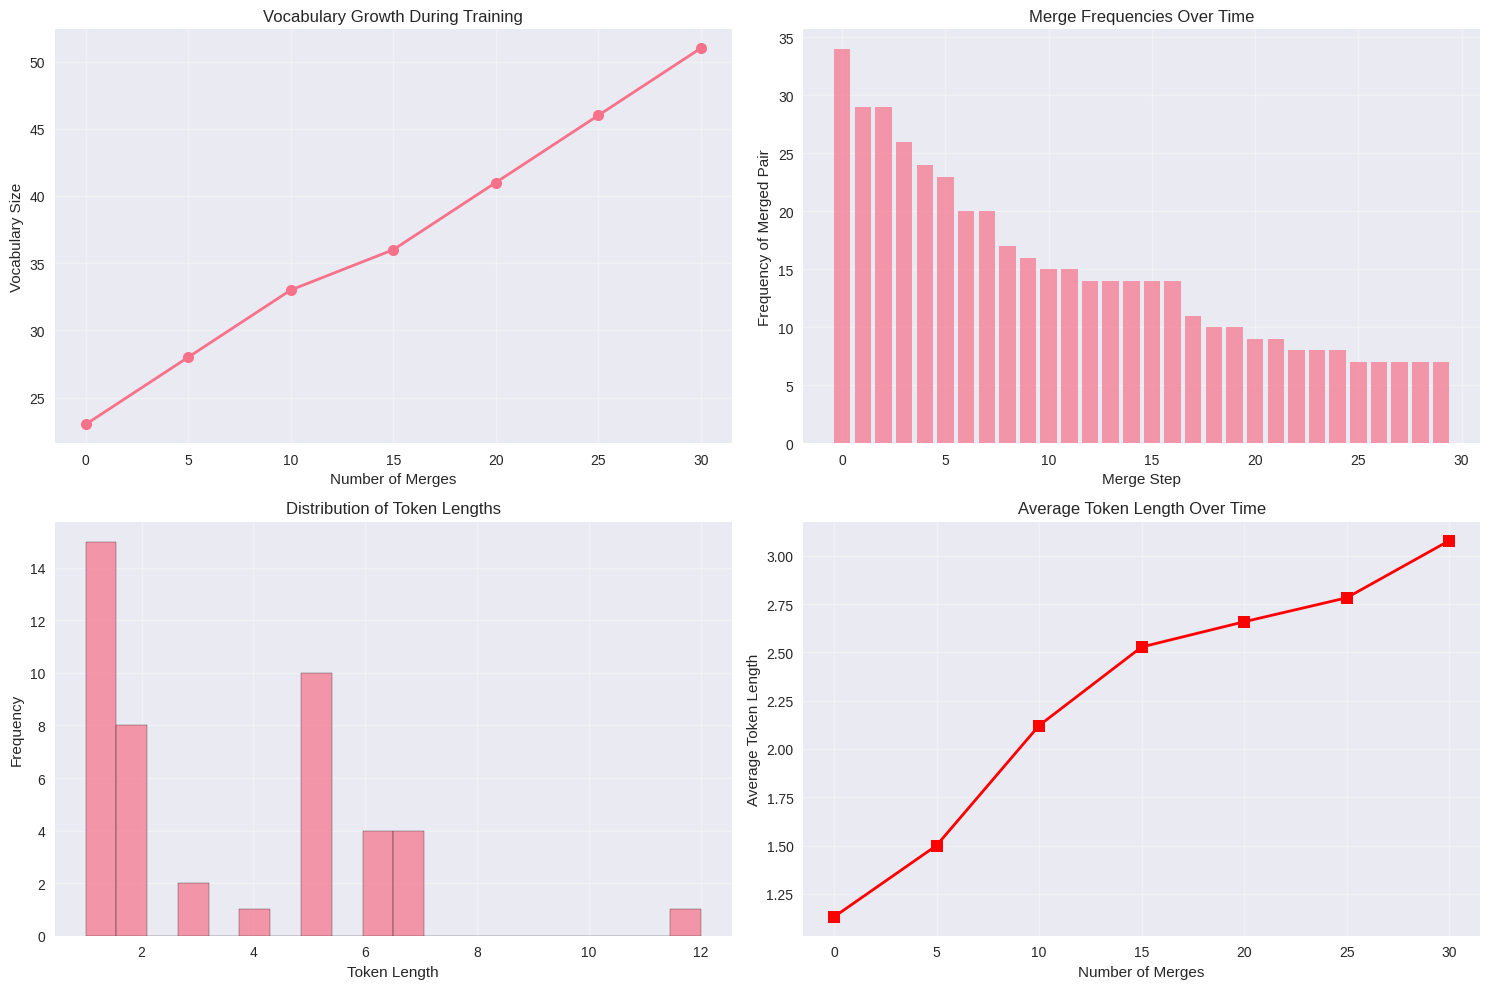

In [4]:
# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Vocabulary growth over time
ax1 = axes[0, 0]
merges = range(0, len(visual_tokenizer.vocab_history) * 5, 5)
vocab_sizes = [h['num_tokens'] for h in visual_tokenizer.vocab_history]

ax1.plot(merges, vocab_sizes, marker='o', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Merges')
ax1.set_ylabel('Vocabulary Size')
ax1.set_title('Vocabulary Growth During Training')
ax1.grid(True, alpha=0.3)

# 2. Merge frequencies
ax2 = axes[0, 1]
ax2.bar(range(len(visual_tokenizer.merge_frequencies)), 
        visual_tokenizer.merge_frequencies, alpha=0.7)
ax2.set_xlabel('Merge Step')
ax2.set_ylabel('Frequency of Merged Pair')
ax2.set_title('Merge Frequencies Over Time')
ax2.grid(True, alpha=0.3)

# 3. Token length distribution
ax3 = axes[1, 0]
token_lengths = [len(t) for t in visual_tokenizer.vocab.keys() 
                 if t not in ['<unk>', '<pad>', '</w>']]
ax3.hist(token_lengths, bins=20, alpha=0.7, edgecolor='black')
ax3.set_xlabel('Token Length')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Token Lengths')
ax3.grid(True, alpha=0.3)

# 4. Average token length over time
ax4 = axes[1, 1]
avg_lengths = [h['avg_token_length'] for h in visual_tokenizer.vocab_history]
ax4.plot(merges, avg_lengths, marker='s', color='red', linewidth=2, markersize=8)
ax4.set_xlabel('Number of Merges')
ax4.set_ylabel('Average Token Length')
ax4.set_title('Average Token Length Over Time')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🔍 Analyzing Merge Patterns

Let's look at what kinds of pairs are being merged and in what order.

In [7]:
# Display first 15 merges with their frequencies
merge_data = []
for i, (pair, freq) in enumerate(zip(visual_tokenizer.merges[:15], 
                                      visual_tokenizer.merge_frequencies[:15])):
    merge_data.append({
        'Step': i+1,
        'Pair': f"{pair[0]} + {pair[1]}",
        'Merged Token': ''.join(pair),
        'Frequency': freq,
        'Type': 'Letters' if len(pair[0]) == 1 and len(pair[1]) == 1 else 'Subwords'
    })

df_merges = pd.DataFrame(merge_data)
df_merges

,Step,Pair,Merged Token,Frequency,Type
0,1,e + </w>,e</w>,34,Subwords
1,2,t + h,th,29,Letters
2,3,d + </w>,d</w>,29,Subwords
3,4,i + s,is,26,Letters
4,5,e + r,er,24,Letters
5,6,s + </w>,s</w>,23,Subwords
6,7,n + </w>,n</w>,20,Subwords
7,8,th + e</w>,the</w>,20,Subwords
8,9,t + </w>,t</w>,17,Subwords
9,10,e + d</w>,ed</w>,16,Subwords


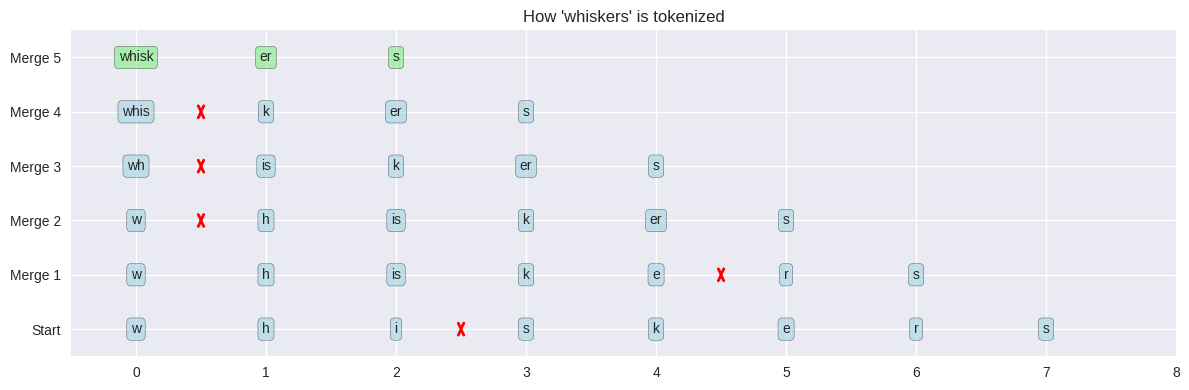

In [8]:
# Visualize the merge hierarchy for a specific word
def visualize_word_construction(word, merges):
    """Show how a word is built from merges."""
    fig, ax = plt.subplots(figsize=(12, 4))
    
    # Start with characters
    chars = list(word)
    tokens = chars.copy()
    
    # Track merges for this word
    y_pos = 0
    for i, merge in enumerate(merges):
        merged = ''.join(merge)
        
        # Check if this merge applies to current tokens
        new_tokens = []
        j = 0
        while j < len(tokens):
            if j < len(tokens) - 1 and tokens[j] == merge[0] and tokens[j+1] == merge[1]:
                new_tokens.append(merged)
                j += 2
            else:
                new_tokens.append(tokens[j])
                j += 1
        
        if new_tokens != tokens:
            # Visualize this merge
            for idx, token in enumerate(tokens):
                ax.text(idx, y_pos, token, ha='center', va='center',
                       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
            
            # Draw arrows for merged pairs
            for idx in range(len(tokens) - 1):
                if tokens[idx] == merge[0] and tokens[idx+1] == merge[1]:
                    ax.annotate('', xy=(idx+0.5, y_pos-0.1), xytext=(idx+0.5, y_pos+0.1),
                               arrowprops=dict(arrowstyle='<->', color='red', lw=2))
            
            tokens = new_tokens
            y_pos += 1
    
    # Show final tokens
    for idx, token in enumerate(tokens):
        ax.text(idx, y_pos, token, ha='center', va='center',
               bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
    
    ax.set_xlim(-0.5, len(word))
    ax.set_ylim(-0.5, y_pos+0.5)
    ax.set_yticks(range(y_pos+1))
    ax.set_yticklabels(['Start'] + [f'Merge {i+1}' for i in range(y_pos)])
    ax.set_title(f"How '{word}' is tokenized")
    plt.tight_layout()
    plt.show()

# Test on a word from our corpus
visualize_word_construction("whiskers", visual_tokenizer.merges[:20])

## 📊 Token Frequency Analysis

Let's analyze which tokens are most common in our vocabulary.

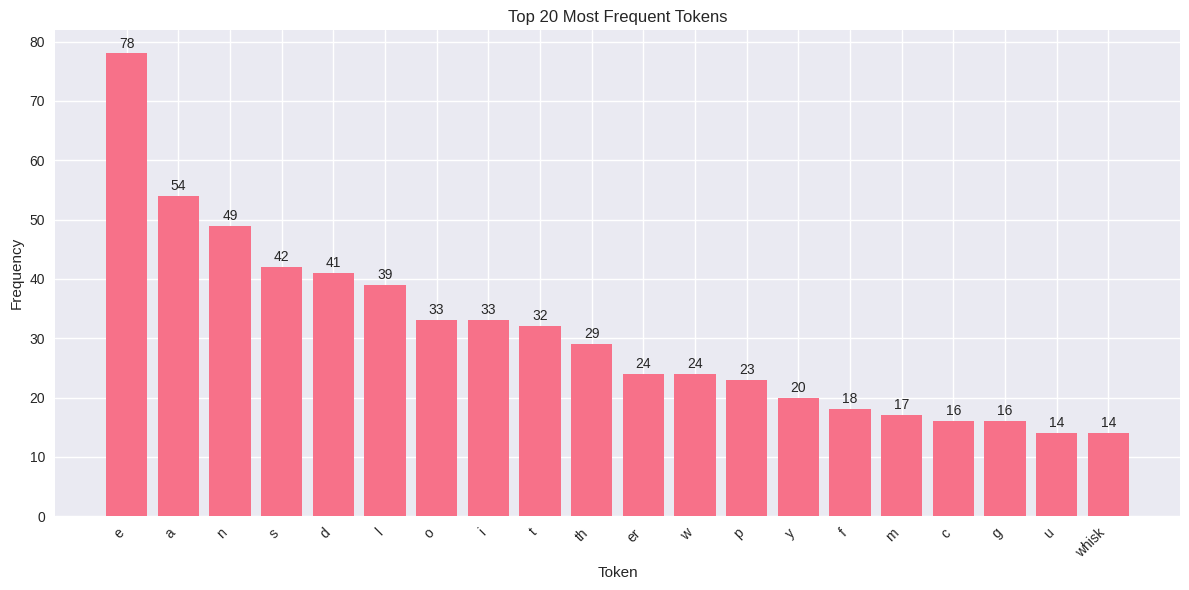

In [9]:
# Build token frequencies from the corpus
token_freqs = Counter()
for story in tinystories_sample:
    words = re.findall(r"\w+", story.lower())
    for word in words:
        # Simple greedy tokenization using our merges
        tokens = []
        remaining = word
        while remaining:
            matched = False
            # Try to match longest token first
            for merge in reversed(visual_tokenizer.merges):
                merged = ''.join(merge)
                if remaining.startswith(merged):
                    tokens.append(merged)
                    remaining = remaining[len(merged):]
                    matched = True
                    break
            if not matched:
                tokens.append(remaining[0])
                remaining = remaining[1:]
        
        token_freqs.update(tokens)

# Plot top 20 tokens
top_tokens = token_freqs.most_common(20)
tokens, freqs = zip(*top_tokens)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(tokens)), freqs)
plt.xticks(range(len(tokens)), tokens, rotation=45, ha='right')
plt.xlabel('Token')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Tokens')

# Add value labels on bars
for bar, freq in zip(bars, freqs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(freq), ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 🔬 Deep Dive: Understanding Merge Decisions

Let's analyze why certain pairs are merged before others.

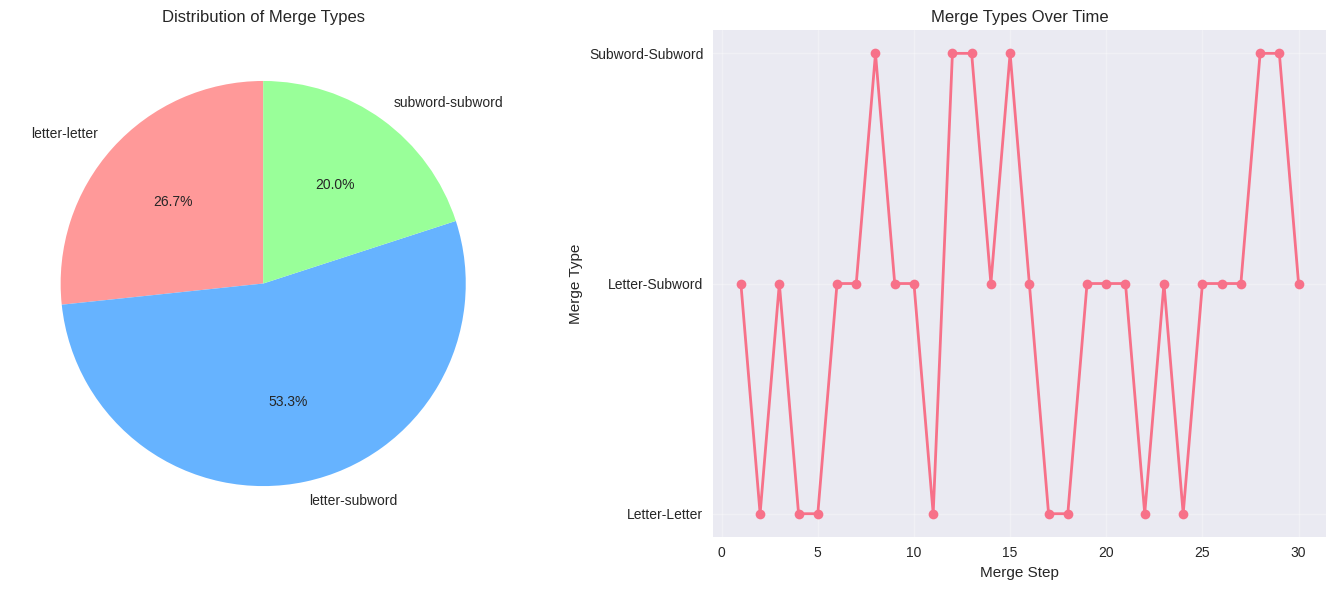

In [10]:
# Analyze merge patterns by type
merge_types = {'letter-letter': 0, 'letter-subword': 0, 'subword-subword': 0}

for pair in visual_tokenizer.merges:
    if len(pair[0]) == 1 and len(pair[1]) == 1:
        merge_types['letter-letter'] += 1
    elif len(pair[0]) > 1 and len(pair[1]) > 1:
        merge_types['subword-subword'] += 1
    else:
        merge_types['letter-subword'] += 1

# Create pie chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart of merge types
colors = ['#ff9999', '#66b3ff', '#99ff99']
ax1.pie(merge_types.values(), labels=merge_types.keys(), autopct='%1.1f%%',
        colors=colors, startangle=90)
ax1.set_title('Distribution of Merge Types')

# Line plot showing when different types occur
type_over_time = []
for i, pair in enumerate(visual_tokenizer.merges[:30]):
    if len(pair[0]) == 1 and len(pair[1]) == 1:
        type_over_time.append(1)
    elif len(pair[0]) > 1 and len(pair[1]) > 1:
        type_over_time.append(3)
    else:
        type_over_time.append(2)

ax2.plot(range(1, len(type_over_time)+1), type_over_time, 'o-', linewidth=2)
ax2.set_xlabel('Merge Step')
ax2.set_ylabel('Merge Type')
ax2.set_yticks([1, 2, 3])
ax2.set_yticklabels(['Letter-Letter', 'Letter-Subword', 'Subword-Subword'])
ax2.set_title('Merge Types Over Time')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📝 Summary and Insights

From our visualizations, we can observe:

1. **Vocabulary Growth**: The vocabulary size increases linearly with merges
2. **Merge Frequency**: Early merges have much higher frequencies than later ones
3. **Token Length Distribution**: Most tokens are short (2-4 characters)
4. **Merge Progression**: 
   - First: Common letter pairs (th, er, in)
   - Then: Common subwords (the, ing, ed)
   - Finally: Whole words (the, and, but)

## 🎯 Key Takeaways for Your Tokenizer

- **Start with character-level**: BPE builds from the ground up
- **Monitor merge frequencies**: They decrease exponentially
- **Consider vocabulary size**: 30-50k tokens is typical for English
- **Handle edge cases**: Unknown tokens, numbers, punctuation